### Importing DataSet

In [1]:
import pandas as pd

df= pd.read_csv('concrete.csv')

df.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [2]:
df.isnull().sum()

cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64

### Train Test Split

In [4]:
from sklearn.model_selection import train_test_split

X=df.drop('strength', axis=1)
Y=df['strength']

X_train, X_test, Y_train, Y_test= train_test_split(X, Y, test_size=0.2, random_state=42)

In [5]:
X_train.skew()

cement          0.493343
slag            0.802065
ash             0.566038
water           0.091973
superplastic    0.897750
coarseagg      -0.041485
fineagg        -0.239988
age             3.335411
dtype: float64

In [ ]:
slag
ash
superplastic
age


### Graphs

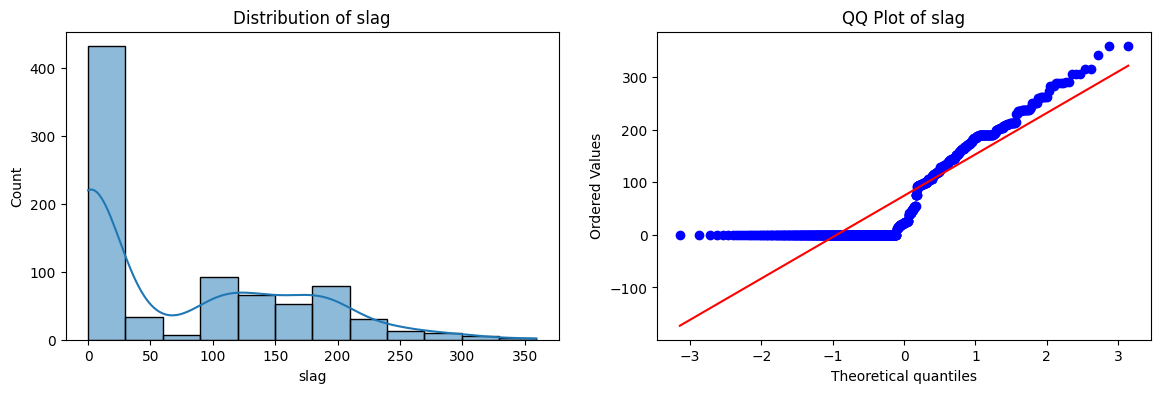

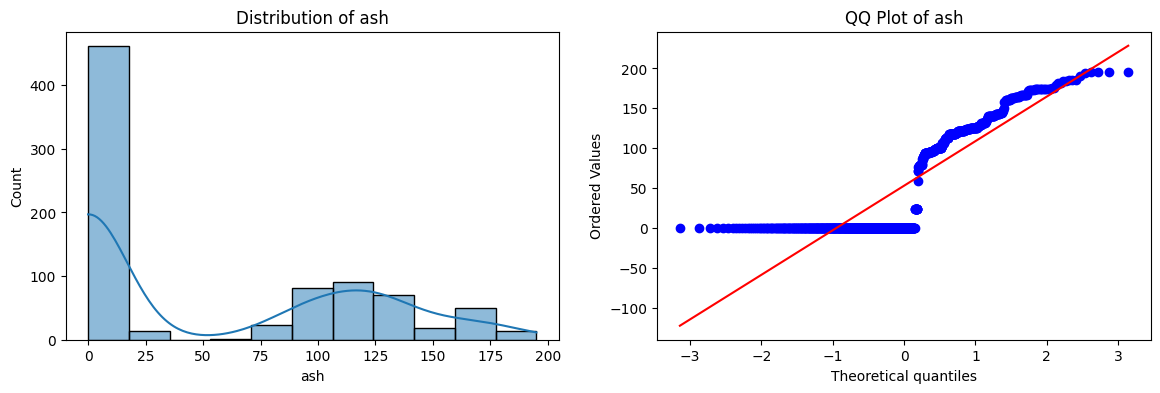

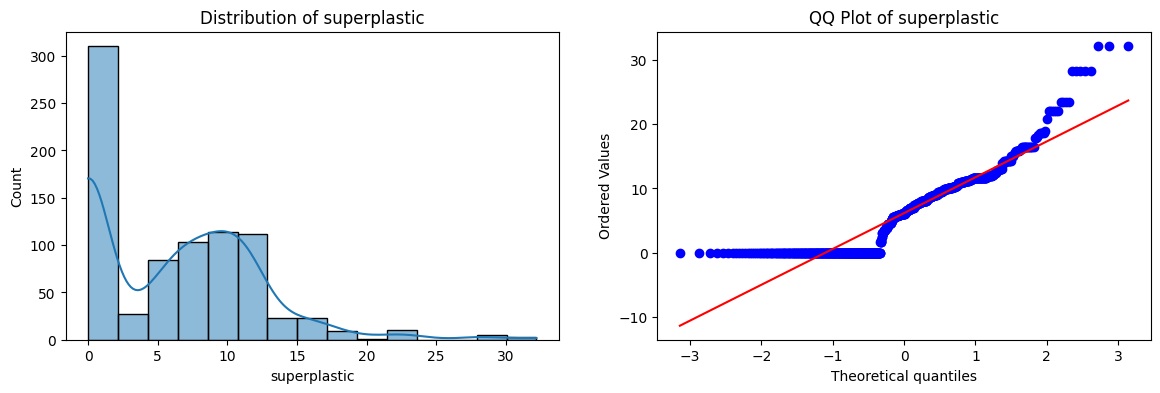

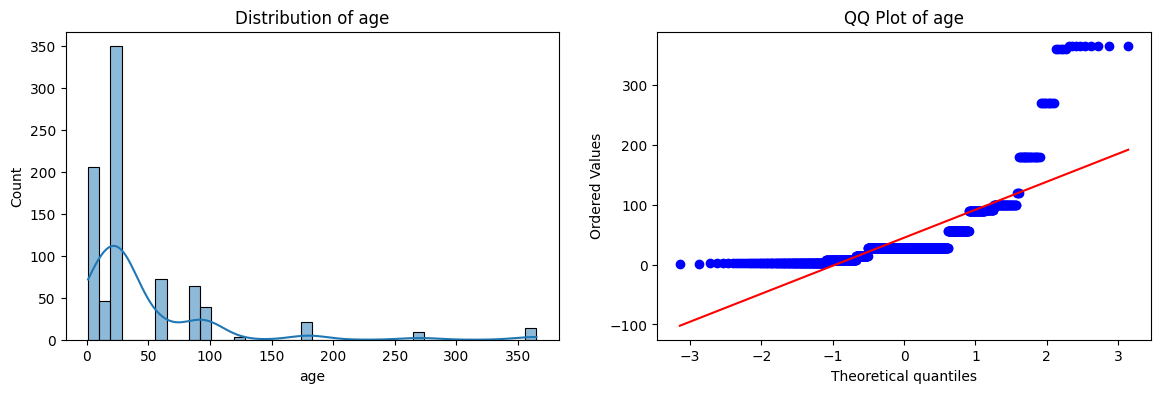

In [15]:
%matplotlib inline

import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats 

columns_to_draw_graph=['slag', 'ash', 'superplastic', 'age']

# 1. Define the function first
def plot_comparison(df, col):
    plt.figure(figsize=(14,4))
    
    # Left: Histogram
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    
    # Right: QQ Plot
    plt.subplot(1,2,2)
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f'QQ Plot of {col}')
    
    plt.show()

# 2. Run the loop
for col in columns_to_draw_graph:
    plot_comparison(X_train, col)

### Feature Scaling

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
import pandas as pd

columns_to_draw_graph=['slag', 'ash', 'superplastic', 'age']

trf=ColumnTransformer(transformers=[
    ('yeo-johnson', PowerTransformer(method='yeo-johnson'), columns_to_draw_graph)
], remainder='passthrough')

### Applying transformation

In [17]:
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.transform(X_test)

### Covert back to Pandas DataFrame

In [18]:
X_train_transformed_df=pd.DataFrame(X_train_transformed, columns=X_train.columns)

### Modified Graphs

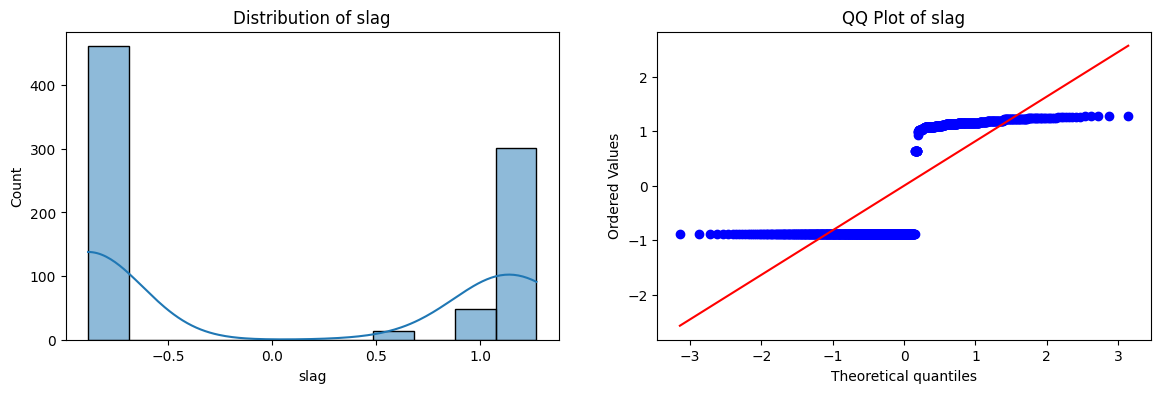

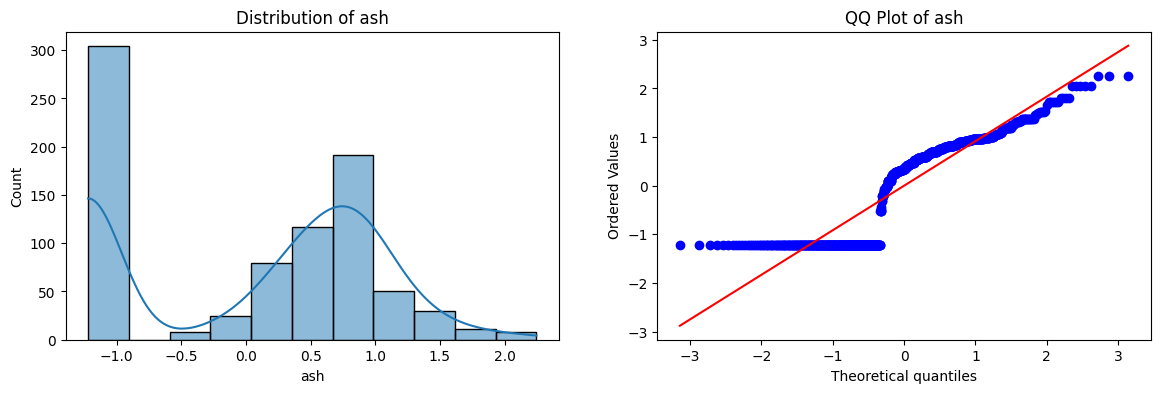

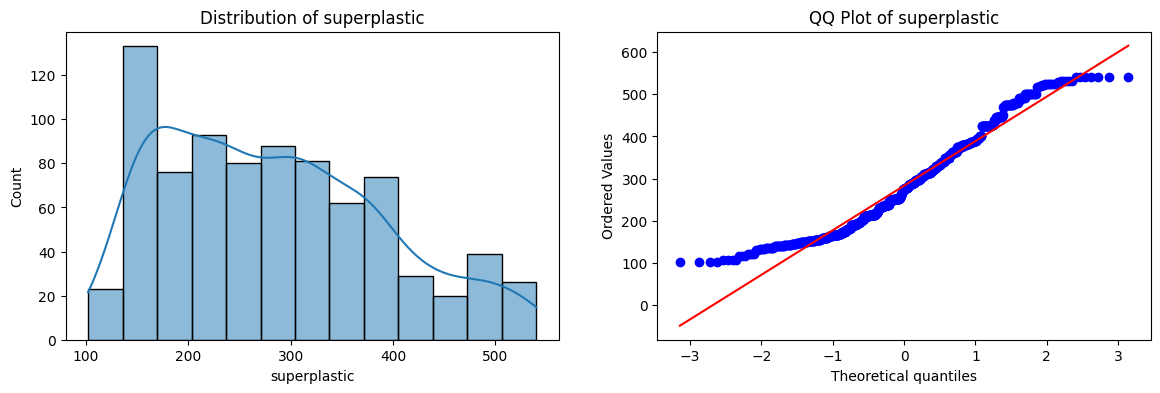

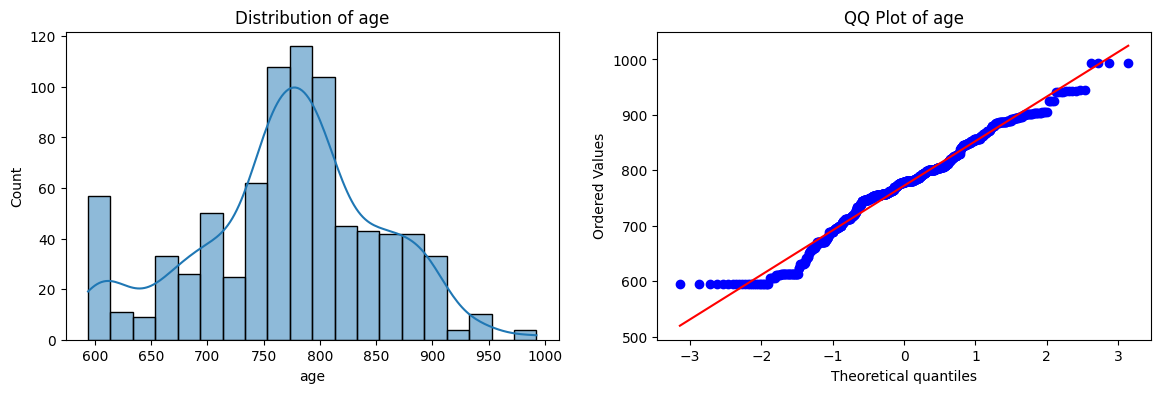

In [20]:
for col in columns_to_draw_graph:
    plot_comparison(X_train_transformed_df, col)

In [21]:
X_train_transformed_df.skew()

cement         -0.023699
slag            0.254891
ash            -0.155090
water          -0.002347
superplastic    0.493343
coarseagg       0.091973
fineagg        -0.041485
age            -0.239988
dtype: float64

In [ ]:
cement          0.493343

ash             0.566038


